# 2 — Predicting interior temperature & humidity (multi-objective, multi-horizon)

**Goal.** Given everything we know about the greenhouse *now*, predict **interior temperature** and **interior humidity** (centre sensor) at three lead times — **+1 h**, **+6 h**, **+12 h** — i.e. **6 quantities at once** (2 variables × 3 horizons): a *multi-objective* regression.

**Special focus of this version: the climatic systems.** The heaters, fog, pumps, blower, recirculators, shade screens and vents in `inside data resampled/` are all included as features. Two design choices make sure they get a *fair* chance to matter, and one analysis *measures* whether they get matter:

1. **Scope to the active period.** Those systems only begin logging in spring; before that their columns are all-zero, which unfairly dilutes them. We restrict the whole study to **from `ACTIVE_START` (2026-04-24)**, when *every* climatic system is online — so they are present in both the train and the test split.
2. **Actuator history features.** A single hour of "on-minutes" is a weak signal; because of thermal/humidity inertia what matters is *how long a device has been running*. We add rolling sums over the last **3 h and 6 h** for every actuator.
3. **Ablation.** We build an escalating ladder of feature sets — *no actuators → + current actuators → + actuator history → + cluster* — and measure the MAE at each rung. That tells us the **marginal value** of the climatic-system data instead of just asserting it.
4. **Fair sequence comparison.** The LSTM originally saw a 24-hour window per prediction while the tabular models saw only the current hour — not an apples-to-apples comparison of *architecture*. Section 2.7c feeds Ridge/RandomForest/HistGB the exact same flattened 24h window the LSTM gets (the `"... (24h hist)"` model variants), and 2.7e / 2.7g add a `lookback=1` (t-only) variant of the LSTM and the attention model respectively, to match the tabular baseline the other way — completing a grid of **{tabular, LSTM, Attention} × {t only, 24h history}**, so 2.8 can separate a *history* effect from an *architecture* effect across three different architectures, not just two.
5. **Attention-based architecture, same fairness rules.** 2.7f/2.7g add a compact attention-based sequence model — one multi-head self-attention block over the 24h window, loosely in the spirit of Temporal Fusion Transformer (TFT) architectures, but deliberately *not* a full TFT (see the note in 2.7f for why: with ~1.2k training rows, a full TFT's variable-selection networks, gating and quantile loss would mostly add parameters to overfit with). It is built from the exact same `make_sequences()` windows, split, targets and metrics as the LSTM, so the LSTM-vs-Attention gap in 2.8 is also an architecture-only comparison.
6. **Day-ahead weather forecast, aligned per horizon — and only that.** `forecast data/hourly_weather_data.csv` carries two kinds of Open-Meteo values: the un-suffixed columns (`FORECAST_FEATURE_COLS`) turn out to be satellite/model "latest run" estimates rather than a genuine advance forecast, so they are **excluded from every model input** (2.3). Only the `*_previous_day1` columns — issued with real ~1-day lead time — are used, aligned per horizon (the `+ day-ahead forecast` rung).
7. **Hyperparameter tuning — a small manual grid for the tabular models, Bayesian optimization for the neural ones.** Ridge/RandomForest/HistGB (2.7b/2.7c) still search a small fixed grid (`alpha`, `min_samples_leaf`, `learning_rate`). The LSTM and the attention model (2.7d–2.7g) are tuned with **KerasTuner's `BayesianOptimization` tuner** instead (`tune_neural()`, 2.7d): rather than trying a fixed list of configurations, it searches `units`, `dropout`, learning rate and `optimizer` as a proper mixed continuous/categorical space, picking each new candidate from a probabilistic model of what is likely to work well given the trials already run. All of it is scored on a chronological hold-out carved from the end of `train`. 2.7h shows what won for each model × rung. Requires `pip install keras-tuner`.

**Two rules that keep the evaluation honest**
* **No leakage** — every feature is known at prediction time (current sensors/actuators, outside weather, the cluster label, and — from the `+ day-ahead forecast` rung on — a forecast with a real lead time). The un-suffixed Open-Meteo `fc_*` columns are not fed to any model (2.3), since they are not genuinely known that far in advance. The hyperparameter search in 2.7b–2.7g is likewise scored on an inner hold-out carved from `train` only — `test` is never touched until final scoring.
* **Chronological split** — train on the earlier period, test on the later one. Never shuffle a time series.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

from greenhouse_dataset import (
    build_hourly_dataset, add_actuator_history, make_targets, TARGET_COLS,
    ACTIVE_START, CONTINUOUS_COLS, ACTUATOR_COLS, EXTERIOR_COLS,
    FORECAST_PREVDAY_FEATURE_COLS, make_forecast_horizon_features,
)

pd.set_option("display.width", 150)
plt.rcParams["figure.figsize"] = (11, 4)


## 2.1 — Load, add actuator history, scope to the active period, attach clusters

We build the hourly table, add the rolling actuator-history columns (`act_*_r3`, `act_*_r6`), then cut everything to the window where the climatic systems are actually operating. We also add the day-ahead forecast, aligned per horizon (`make_forecast_horizon_features`, see 2.3 for why). Finally we join the cluster labels from notebook 1 and one-hot encode them.


In [2]:
df = build_hourly_dataset(root=".")
hist_cols = add_actuator_history(df, windows=(3, 6))     # act_*_r3, act_*_r6
print(f"added {len(hist_cols)} actuator-history features, e.g. {hist_cols[:4]}")

df = df.loc[ACTIVE_START:]                                # <-- re-scope
print("active-period span:", df.index.min(), "->", df.index.max(), "|", len(df), "hours")

clusters = pd.read_csv("model data/clusters.csv", index_col=0, parse_dates=True)["cluster"]
cluster_ohe = pd.get_dummies(clusters, prefix="clu").astype(float)
df = df.join(cluster_ohe)
cluster_cols = list(cluster_ohe.columns)
df[cluster_cols] = df[cluster_cols].fillna(0.0)
print("cluster dummies present in window:",
      [c for c in cluster_cols if df[c].sum() > 0])

fc_hist_cols = make_forecast_horizon_features(df, horizons=(1, 6, 12))
print(f"added {len(fc_hist_cols)} day-ahead forecast features, e.g. {fc_hist_cols[:4]}")


note: fc_temp_prevday still missing 364h after interpolation; backfilling from fc_temp
note: fc_hum_prevday still missing 364h after interpolation; backfilling from fc_hum
note: fc_viento_prevday still missing 260h after interpolation; backfilling from fc_viento
added 26 actuator-history features, e.g. ['act_calefactores_r3', 'act_calefactores_r6', 'act_fog_r3', 'act_fog_r6']
active-period span: 2026-04-24 00:00:00 -> 2026-07-13 22:00:00 | 1943 hours
cluster dummies present in window: ['clu_0', 'clu_1', 'clu_2', 'clu_3', 'clu_4', 'clu_5', 'clu_6', 'clu_7']
added 15 day-ahead forecast features, e.g. ['fc_temp_prevday_h1', 'fc_temp_prevday_h6', 'fc_temp_prevday_h12', 'fc_hum_prevday_h1']


In [3]:
df

,temp_alta,temp_baja,temp_centro,hum_alta,hum_baja,hum_centro,pres_baro_alta,pres_baro_baja,pres_baro_centro,pres_vapor_alta,...,fc_hum_prevday_h12,fc_precip_prevday_h1,fc_precip_prevday_h6,fc_precip_prevday_h12,fc_viento_prevday_h1,fc_viento_prevday_h6,fc_viento_prevday_h12,fc_rad_prevday_h1,fc_rad_prevday_h6,fc_rad_prevday_h12
time,,,,,,,,,,,,,,,,,,,,,
2026-04-24 00:00:00,16.907527,16.618750,16.626281,73.472222,76.136364,77.181579,100.593514,100.632051,1008.412526,1.412813,...,39.414593,0.0,0.0,0.0,0.111803,1.484924,0.316228,0.0,15.0,706.0
2026-04-24 01:00:00,16.220588,15.827835,15.904775,74.708333,77.970588,78.686071,100.526867,100.566410,1007.771099,1.376735,...,47.167670,0.0,0.0,0.1,0.364005,1.414214,0.604152,0.0,118.0,490.0
2026-04-24 02:00:00,15.708511,15.417476,15.435217,75.117647,77.753425,78.876319,100.502821,100.543514,1007.533452,1.342500,...,63.458977,0.0,0.0,0.6,0.721110,1.167262,1.051190,0.0,219.0,275.0
2026-04-24 03:00:00,15.448598,15.127083,15.177257,74.985714,76.945205,77.909934,100.523247,100.564691,1007.750591,1.310841,...,70.109750,0.0,0.0,1.1,1.101136,0.848528,1.569236,0.0,329.0,189.0
2026-04-24 04:00:00,14.947115,14.654808,14.733860,76.325301,78.300000,79.391233,100.539205,100.582532,1007.914021,1.296863,...,75.221120,0.0,0.0,1.4,1.379311,0.531507,2.089258,0.0,328.0,89.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-13 18:00:00,32.484536,31.639175,32.048163,57.494118,62.612903,62.140490,100.129130,100.167619,1004.055155,2.815593,...,NaN,0.0,NaN,NaN,3.696282,NaN,NaN,102.0,NaN,NaN
2026-07-13 19:00:00,30.364130,30.381522,30.502536,62.362319,63.805970,63.968864,100.197500,100.238696,1004.722423,2.713611,...,NaN,0.0,NaN,NaN,2.294014,NaN,NaN,6.0,NaN,NaN
2026-07-13 20:00:00,29.073864,29.028889,29.169756,65.698413,67.898551,67.379215,100.257059,100.299559,1005.318446,2.639541,...,NaN,0.0,NaN,NaN,1.140176,NaN,NaN,0.0,NaN,NaN


## 2.2 — Build the targets

Shift the centre temperature and humidity **back** by each horizon so row *t* carries the value observed at *t+h*.

In [4]:
targets = make_targets(df, temp_col="temp_centro", hum_col="hum_centro",
                       horizons=(1, 6, 12))
print("targets:", TARGET_COLS)
targets.head()

targets: ['temp_h1', 'hum_h1', 'temp_h6', 'hum_h6', 'temp_h12', 'hum_h12']


,temp_h1,hum_h1,temp_h6,hum_h6,temp_h12,hum_h12
time,,,,,,
2026-04-24 00:00:00,15.904775,78.686071,14.899074,79.809038,25.457528,45.066298
2026-04-24 01:00:00,15.435217,78.876319,15.373333,77.426667,25.873268,44.463548
2026-04-24 02:00:00,15.177257,77.909934,21.561975,55.423788,25.412527,44.783048
2026-04-24 03:00:00,14.733860,79.391233,25.838929,45.972019,24.535730,53.939559
2026-04-24 04:00:00,14.219767,80.987760,25.925117,44.604641,21.387315,69.703302


## 2.3 — Feature sets: the ablation ladder

Every rung adds one more group of information on top of the previous one, so the change in error isolates each group's contribution:

| rung | contents |
|---|---|
| **no actuators** | interior climate + exterior weather + time |
| **+ actuators (current)** | above **+** this-hour on-minutes of each climatic system |
| **+ actuator history** | above **+** rolling 3 h / 6 h running totals |
| **+ cluster** | above **+** the regime label from notebook 1 |
| **+ day-ahead forecast** | above **+** the `previous_day1` forecast value for the *target* hour t+h, one column per variable per horizon |

The *climate* block already contains the interior temperature/humidity/pressure, so it is a strong base — the question is how much the **climatic-system** blocks add on top.

**`FORECAST_FEATURE_COLS` is deliberately excluded from `climate`.** The un-suffixed Open-Meteo columns (`fc_temp`, `fc_hum`, `fc_precip`, `fc_viento`, `fc_rad`) come from the Open-Meteo *Previous Runs API*'s "latest available run" for each timestamp — for a date now in the past, that's effectively the most recent satellite/model-blended estimate, not something forecastable with real lead time on the day itself. `greenhouse_dataset.py` still reads them (used only to backfill a small gap in the `previous_day1` series — see the note in that file), but they are no longer fed to any model as a feature.

**The only forecast information the models see is `previous_day1`.** Open-Meteo's `*_previous_day1` columns are the forecast values as issued by the model run from about a day before the target hour — a genuine, honestly-available-in-advance forecast. `make_forecast_horizon_features()` (2.1) builds one column per forecast variable per horizon, shifting each `previous_day1` series back by *h* exactly the way `make_targets()` builds the targets themselves — so row *t* carries "what was forecast a day ago for hour *t+h*". Since the horizons here (≤12h) are well inside that ~1-day lead time, this is safe: the forecast for *t+h* was already issued before *t*. That's what the **`+ day-ahead forecast`** rung uses — and now it's the only rung carrying any forecast-derived feature at all.


In [5]:
time_feats = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "hour", "month"]
climate = CONTINUOUS_COLS + EXTERIOR_COLS + time_feats   # FORECAST_FEATURE_COLS dropped, see 2.3

feature_sets = {
    "no actuators":           climate,
    "+ actuators (current)":  climate + ACTUATOR_COLS,
    "+ actuator history":     climate + ACTUATOR_COLS + hist_cols,
    "+ cluster":              climate + ACTUATOR_COLS + hist_cols + cluster_cols,
    "+ day-ahead forecast":   climate + ACTUATOR_COLS + hist_cols + cluster_cols + fc_hist_cols,
}
actuator_features = ACTUATOR_COLS + hist_cols     # everything "climatic-system"

all_cols = climate + ACTUATOR_COLS + hist_cols + cluster_cols + fc_hist_cols
required = climate + ACTUATOR_COLS + hist_cols + fc_hist_cols   # cluster dummies may be 0
data = df[all_cols].join(targets).dropna(subset=required + TARGET_COLS)
print("modelling rows:", len(data), "| candidate features:", len(all_cols))


modelling rows: 1472 | candidate features: 86


In [6]:
data

,temp_alta,temp_baja,temp_centro,hum_alta,hum_baja,hum_centro,pres_baro_alta,pres_baro_baja,pres_baro_centro,pres_vapor_alta,...,fc_viento_prevday_h12,fc_rad_prevday_h1,fc_rad_prevday_h6,fc_rad_prevday_h12,temp_h1,hum_h1,temp_h6,hum_h6,temp_h12,hum_h12
time,,,,,,,,,,,,,,,,,,,,,
2026-04-24 00:00:00,16.907527,16.618750,16.626281,73.472222,76.136364,77.181579,100.593514,100.632051,1008.412526,1.412813,...,0.316228,0.0,15.0,706.0,15.904775,78.686071,14.899074,79.809038,25.457528,45.066298
2026-04-24 01:00:00,16.220588,15.827835,15.904775,74.708333,77.970588,78.686071,100.526867,100.566410,1007.771099,1.376735,...,0.604152,0.0,118.0,490.0,15.435217,78.876319,15.373333,77.426667,25.873268,44.463548
2026-04-24 02:00:00,15.708511,15.417476,15.435217,75.117647,77.753425,78.876319,100.502821,100.543514,1007.533452,1.342500,...,1.051190,0.0,219.0,275.0,15.177257,77.909934,21.561975,55.423788,25.412527,44.783048
2026-04-24 03:00:00,15.448598,15.127083,15.177257,74.985714,76.945205,77.909934,100.523247,100.564691,1007.750591,1.310841,...,1.569236,0.0,329.0,189.0,14.733860,79.391233,25.838929,45.972019,24.535730,53.939559
2026-04-24 04:00:00,14.947115,14.654808,14.733860,76.325301,78.300000,79.391233,100.539205,100.582532,1007.914021,1.296863,...,2.089258,0.0,328.0,89.0,14.219767,80.987760,25.925117,44.604641,21.387315,69.703302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-13 06:00:00,27.659524,27.962791,27.785680,84.695652,81.453125,84.937919,99.132188,100.321231,1005.580568,3.019626,...,3.460130,202.0,919.0,272.0,29.854713,76.615348,36.364627,70.521518,32.048163,62.140490
2026-07-13 07:00:00,29.936634,30.671111,29.854713,73.324675,71.821918,76.615348,100.282090,100.324853,1005.690281,3.097949,...,3.696282,380.0,933.0,102.0,32.316291,68.490995,37.504662,70.364560,30.502536,63.968864
2026-07-13 08:00:00,31.721978,32.222472,32.316291,67.183099,66.455882,68.490995,100.300000,100.343016,1005.874317,3.127500,...,2.294014,530.0,868.0,6.0,33.936081,68.590995,36.638246,69.486893,29.169756,67.379215


## 2.4 — Chronological train / test split

First 80 % of the (now shorter) active-period timeline for training, last 20 % for testing. Note the trade-off of re-scoping: fewer rows and a summer-only test window — the systems participate fairly, but seasonal diversity is reduced.

In [7]:
n = len(data); cut = int(n * 0.80)
train, test = data.iloc[:cut], data.iloc[cut:]
print(f"train: {train.index.min()} -> {train.index.max()}  ({len(train)} h)")
print(f"test : {test.index.min()} -> {test.index.max()}  ({len(test)} h)")
y_train, y_test = train[TARGET_COLS], test[TARGET_COLS]

train: 2026-04-24 00:00:00 -> 2026-07-01 03:00:00  (1177 h)
test : 2026-07-01 04:00:00 -> 2026-07-13 10:00:00  (295 h)


## 2.5 — Metrics: **MAE**, **CVRMSE** (RMSE ÷ mean, as used elsewhere in the repo), and **R²**, per target.

In [8]:
def cvrmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred) / np.mean(y_true)

def score(y_true_df, y_pred_df):
    return pd.DataFrame({
        "MAE":    {c: mean_absolute_error(y_true_df[c], y_pred_df[c]) for c in TARGET_COLS},
        "CVRMSE": {c: cvrmse(y_true_df[c], y_pred_df[c]) for c in TARGET_COLS},
        "R2":     {c: np.corrcoef(y_true_df[c], y_pred_df[c])[0][1]**2 for c in TARGET_COLS},
    })

## 2.6 — Persistence baseline — *"in h hours it will be what it is now."*

In [9]:
persist = pd.DataFrame(index=test.index)
for h in (1, 6, 12):
    persist[f"temp_h{h}"] = df["temp_centro"].reindex(test.index)
    persist[f"hum_h{h}"]  = df["hum_centro"].reindex(test.index)
baseline_scores = score(y_test, persist[TARGET_COLS])
baseline_scores.round(2)

,MAE,CVRMSE,R2
temp_h1,1.18,0.05,0.92
hum_h1,2.87,0.05,0.84
temp_h6,6.14,0.24,0.00
hum_h6,10.08,0.18,0.01
temp_h12,8.71,0.33,0.83
hum_h12,10.76,0.18,0.00


## 2.7 — Train every model on every rung of the ladder

* **Ridge** — linear, standardised, natively multi-output.
* **RandomForest** — non-linear, natively multi-output.
* **HistGradientBoosting** — strong tabular booster, one per target via `MultiOutputRegressor`.
* **The same three, on 24h raw history** — same estimators, but fed the flattened 24h window instead of just "now" (2.7c), so they can be compared to the LSTM and the attention model on equal informational footing.
* **LSTM** — sequence model (2.7d), trained on the exact same 24h windows as the "(24h hist)" tabular models above, on the same rungs, added to the same `results`/`predictions` stores so it flows through every comparison below.
* **LSTM (t only)** — the same LSTM architecture, but with `lookback=1` (2.7e), so it sees only the current hour, just like the single-timestep tabular models in 2.7b.
* **Attention** — a compact Transformer-encoder block (2.7f): multi-head self-attention over the same 24h windows as the LSTM, loosely TFT-inspired but deliberately scaled down (see 2.7f). Same rungs, same split, same stores.
* **Attention (t only)** — the same block with `lookback=1` (2.7g), completing the grid — {tabular, LSTM, Attention} × {t only, 24h history} — so an architecture effect and a history effect can each be read on their own, across three architectures instead of two.
* **Hyperparameter tuning for all of them.** Ridge/RandomForest/HistGB pick from a small fixed grid (`alpha` / `min_samples_leaf` / `learning_rate`); the LSTM and Attention models are tuned by **KerasTuner's `BayesianOptimization`** over `units`, `dropout`, learning rate and `optimizer` (`tune_neural()`, 2.7d) instead of a fixed list — all scored on a chronological hold-out inside `train`. See 2.7h for what won per model × rung.


## 2.7a — Shared 24h-history sequence builder

Both the "(24h hist)" tabular models and the LSTM need the *same* 24-hour windows of every feature — that's what makes the comparison in 2.7c/2.7d fair. `make_sequences()` builds them once: for each rung it fits the `StandardScaler` for features and targets on the *train* rows only, then slides a `LOOKBACK`-hour window over the whole time-ordered table so every test-set window ends exactly on a test-set hour (no test target ever leaks into a window). It returns 3D arrays `(n_samples, lookback, n_features)` — the LSTM consumes them as-is, the tabular models flatten them to `(n_samples, lookback * n_features)`.


In [10]:
LOOKBACK = 24  # hours of history fed to every "24h hist" model (tabular-flattened and LSTM alike)

def make_sequences(cols, lookback=LOOKBACK):
    """Slide a `lookback`-hour window over `data[cols]` -> `data[TARGET_COLS]`.

    Scalers are fit on the train rows only; sequences are built over the
    whole table so test-set windows can reach back into the train period
    without losing any test rows. Returns 3D arrays `(n, lookback, n_features)`
    — flatten to 2D for the tabular models (2.7c), keep 3D for the LSTM (2.7d).
    Same underlying data either way: that's the point.
    """
    X_all = data[cols].to_numpy(dtype="float32")
    y_all = data[TARGET_COLS].to_numpy(dtype="float32")

    x_scaler = StandardScaler().fit(X_all[:cut])
    y_scaler = StandardScaler().fit(y_all[:cut])
    X_scaled = x_scaler.transform(X_all).astype("float32")
    y_scaled = y_scaler.transform(y_all).astype("float32")

    idx = np.arange(lookback - 1, len(data))
    X_seq = np.stack([X_scaled[i - lookback + 1: i + 1] for i in idx])
    y_seq = y_scaled[idx]
    time_seq = data.index[idx]

    train_sel = time_seq <= train.index.max()
    test_sel = time_seq >= test.index.min()
    return X_seq[train_sel], y_seq[train_sel], X_seq[test_sel], y_scaler, time_seq[test_sel]


## 2.7b — Tabular models, single timestep (t only) — the original ladder, now with small hyperparameter tuning

Ridge / RandomForest / HistGB see one row of "now" per prediction — whatever temporal context they get comes only from engineered features (cyclical time, actuator rolling sums), not from the model seeing past rows directly.

Each model now searches a small grid per rung (`model_search_space()` / `fit_best()`, defined below): Ridge over `alpha`, RandomForest over `min_samples_leaf`, HistGB over `learning_rate`. Candidates are scored on a chronological 15% hold-out carved from the end of `train` (never touching `test`); the winner is refit on the *full* `train`, and the winning hyperparameters are logged in `best_params_log` for 2.7f.


In [11]:
def model_search_space():
    """model name -> (constructor(params) -> unfitted estimator, small param grid)."""
    return {
        "Ridge": (
            lambda p: make_pipeline(StandardScaler(), Ridge(alpha=p["alpha"])),
            [{"alpha": a} for a in (0.1, 1.0, 10.0, 100.0)],
        ),
        "RandomForest": (
            lambda p: RandomForestRegressor(
                n_estimators=200, min_samples_leaf=p["min_samples_leaf"],
                n_jobs=-1, random_state=0),
            [{"min_samples_leaf": v} for v in (1, 2, 5)],
        ),
        "HistGB": (
            lambda p: MultiOutputRegressor(HistGradientBoostingRegressor(
                max_iter=300, learning_rate=p["learning_rate"], random_state=0)),
            [{"learning_rate": v} for v in (0.03, 0.05, 0.1)],
        ),
    }

def fit_best(model_ctor, param_grid, X, y, val_frac=0.15):
    """Chronologically hold out the last `val_frac` of (X, y) to score each
    candidate in `param_grid` by mean MAE, then refit the winner on the FULL
    (X, y). Never touches the real test set — this is a nested, in-train-only
    search, the tabular equivalent of the LSTM's `validation_split`.
    """
    X = np.asarray(X); y = np.asarray(y)
    cut_inner = int(len(X) * (1 - val_frac))
    X_tr, y_tr = X[:cut_inner], y[:cut_inner]
    X_val, y_val = X[cut_inner:], y[cut_inner:]

    best_mae, best_params = np.inf, param_grid[0]
    for params in param_grid:
        m = model_ctor(params)
        m.fit(X_tr, y_tr)
        mae = mean_absolute_error(y_val, m.predict(X_val))
        if mae < best_mae:
            best_mae, best_params = mae, params

    final_model = model_ctor(best_params)
    final_model.fit(X, y)
    return final_model, best_params

results, predictions, best_params_log = {}, {}, {}
for fs_name, cols in feature_sets.items():
    for m_name, (ctor, grid) in model_search_space().items():
        model, best_p = fit_best(ctor, grid, train[cols], y_train)
        pred = pd.DataFrame(model.predict(np.asarray(test[cols])), index=test.index, columns=TARGET_COLS)
        results[(m_name, fs_name)] = score(y_test, pred)
        predictions[(m_name, fs_name)] = pred
        best_params_log[(m_name, fs_name)] = best_p
print("trained", len(results), "model x feature-set combinations (each tuned over a small grid)")


trained 15 model x feature-set combinations (each tuned over a small grid)


## 2.7c — Tabular models, 24h raw history (flattened) — fair comparison with the LSTM, same tuning

Same three estimators as 2.7b, same rungs, same split, same small hyperparameter search (`model_search_space()` / `fit_best()`, 2.7b) — but now fit on the flattened `(lookback * n_features)` window from `make_sequences()` instead of a single row. This is the input the LSTM also sees (2.7d), just unrolled into one row instead of kept as a sequence, so any gap between these and the LSTM is attributable to *architecture*, not to one side having more history (or more tuning) than the other. Predictions are inverse-scaled back to the original units before scoring, same as the LSTM.

Note this multiplies the column count by `LOOKBACK` (e.g. a rung with 60 columns becomes ~1,440) while the training set stays ~1.2k rows — a much higher columns-to-rows ratio than 2.7b, so don't be surprised if the tuned `alpha` for Ridge lands higher here than in 2.7b (2.7f shows exactly what was picked).


In [12]:
for fs_name, cols in feature_sets.items():
    Xtr_seq, ytr, Xte_seq, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "24h-history sequences must line up with the tabular test split"

    Xtr_flat = Xtr_seq.reshape(len(Xtr_seq), -1)   # (n_train, lookback * n_features)
    Xte_flat = Xte_seq.reshape(len(Xte_seq), -1)

    for m_name, (ctor, grid) in model_search_space().items():
        model, best_p = fit_best(ctor, grid, Xtr_flat, ytr)
        pred_scaled = model.predict(Xte_flat)
        pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled),
                            index=test.index, columns=TARGET_COLS)
        key_name = f"{m_name} (24h hist)"
        results[(key_name, fs_name)] = score(y_test, pred)
        predictions[(key_name, fs_name)] = pred
        best_params_log[(key_name, fs_name)] = best_p

n_hist = sum(1 for k in results if k[0].endswith("(24h hist)"))
print(f"trained {n_hist} tabular model x feature-set combinations on flattened 24h history "
      f"({Xtr_flat.shape[1]} columns for the last rung alone, each tuned over a small grid)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.826363747019059e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.369820428782532e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.2030090579837633e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice

trained 15 tabular model x feature-set combinations on flattened 24h history (2064 columns for the last rung alone, each tuned over a small grid)


## 2.7d — LSTM (sequence model), same ladder, same split, same raw inputs as "(24h hist)"

The single-timestep tabular models in 2.7b see one row of "now" per prediction. The LSTM instead sees the last **`LOOKBACK` = 24 hours** of every feature in a rung and learns temporal patterns (daily cycle, actuator run-up, thermal inertia) directly from the sequence — via `make_sequences()` (2.7a), the exact same windows that feed the "(24h hist)" tabular models in 2.7c, just kept 3D here instead of flattened. That is what makes the LSTM-vs-"(24h hist)" comparison fair: same rows, same columns, same 24h window, same scaling, same split — only the architecture differs.

To keep the comparison honest with the tabular ladder:
* **Same chronological split** — the `StandardScaler` for both features and targets is fit on the *train* rows only; sequences are built by sliding a 24 h window over the full time-ordered table, so every test-set sequence's window ends exactly on a test-set hour (no test targets ever leak into a window).
* **Same rungs** — one LSTM is trained per entry of `feature_sets`, exactly like the tabular loops.
* **Same targets, same metrics** — predictions are scored with the same `score()` (MAE / CVRMSE / R²) against the same `y_test`, and dropped into the same `results` / `predictions` dictionaries under the model name `"LSTM"`, so the ladder table, the best-model report, and the comparison chart below pick it up automatically.
* **Tuned with KerasTuner's `BayesianOptimization`, not a fixed list.** `tune_neural()` (below) wraps a `kt.BayesianOptimization` search over `units`, `dropout`, learning rate and `optimizer` — a genuine mixed continuous/categorical hyperparameter space rather than a hand-picked short list. Each of `max_trials` candidates is scored the same way the tabular models are: fit on `(Xtr, ytr)` with Keras' own `validation_split=0.15` (the same holdout used for `EarlyStopping`), never touching `test`. Bayesian optimization keeps a probabilistic model of "hyperparameters → validation loss" learned from the trials already run, and picks each next candidate to try based on that model — so a small trial budget can cover the space more usefully than the same number of arbitrary grid points. `max_trials` is kept small (8) to bound runtime, which is also why `overwrite=True` is set: every notebook run starts a fresh search rather than resuming whatever an earlier run left in the `kt_tuning/` directory on disk. `tune_neural()` is shared with the attention model in 2.7f/2.7g, so both neural architectures are tuned identically. Requires `pip install keras-tuner`.
* **Winner is rebuilt and retrained fresh, not pulled from the tuner's checkpoint.** `tuner.get_best_models()` reloads the best trial's saved weights into a newly-constructed model — but that model's optimizer hasn't taken a training step yet, so it only has its 2 bookkeeping variables built (e.g. iteration count) versus the ~16 slot variables (per-weight momentum/velocity) the saved optimizer checkpoint has. Keras notices the mismatch and skips loading the optimizer state, printing a `UserWarning: Skipping variable loading for optimizer 'adam'...`. The **model weights still load correctly** — only the optimizer's momentum/velocity state doesn't — so the warning is harmless *if* you don't keep training that model further. `tune_neural()` sidesteps it entirely instead of just suppressing the message: it rebuilds the winning hyperparameters with a brand-new `build_model(best_hp)` and retrains once more (same `validation_split=0.15` / early stopping as every trial), so the returned model's optimizer is built organically through that fit rather than loaded from a checkpoint. This costs one extra fit per rung (`max_trials + 1` instead of `max_trials`) but is the pattern KerasTuner's own docs recommend for exactly this reason.

Building sequences from the start of `data` costs the *train* split its first 23 rows (no history exists before the dataset begins); the *test* split loses nothing, since its history reaches back into the train period.

2.7e adds the fourth cell of the grid: the same architecture and tuning with `lookback=1`, isolating what the recurrent architecture buys on its own, with no history advantage over the tabular models in 2.7b. 2.7f/2.7g repeat both variants for the attention model, completing a 3×2 grid of architectures × input regimes.


In [13]:
KT_DIR = "kt_tuning"   # keras-tuner scratch directory; safe to delete between runs

def _safe_name(s):
    """Turn a feature-set name like "+ day-ahead forecast" into something
    usable as a keras-tuner project_name / directory component."""
    return "".join(c if c.isalnum() else "_" for c in s)

def make_optimizer(name, lr):
    ctor = {"adam": keras.optimizers.Adam, "rmsprop": keras.optimizers.RMSprop}[name]
    return ctor(lr)

def make_lstm(n_features, n_targets, lookback=LOOKBACK, units=64, dropout=0.0, lr=1e-3, optimizer="adam"):
    keras.utils.set_random_seed(0)
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(units, dropout=dropout),
        layers.Dense(32, activation="tanh"),
        layers.Dense(n_targets),
    ])
    model.compile(optimizer=make_optimizer(optimizer, lr), loss="mse")
    return model

def tune_neural(make_model_fn, n_features, n_targets, lookback, Xtr, ytr, project_name,
               max_trials=20, seed=0):
    """Bayesian-optimize `make_model_fn`'s hyperparameters with KerasTuner
    instead of trying a fixed list. Each candidate is scored by fitting on
    (Xtr, ytr) with validation_split=0.15 (mirrors fit_best()'s inner holdout
    in 2.7b, just reusing Keras' own split instead of a second manual one),
    early-stopped on val_loss. `overwrite=True` means a rerun always starts a
    fresh search instead of resuming trials left on disk under KT_DIR.

    The winner is rebuilt from scratch and retrained (rather than pulled via
    `tuner.get_best_models()`) to avoid a UserWarning: reloading a search
    trial's saved weights into a freshly-constructed optimizer trips a
    variable-count mismatch (a just-built optimizer has ~2 bookkeeping
    variables; a fitted one has slot variables per weight, e.g. 16) because
    the optimizer's own state was never meant to be restored this way. See
    the note in the 2.7d markdown for the full explanation.
    """
    def build_model(hp):
        units = hp.Int("units", 16, 128, step=16)
        dropout = hp.Float("dropout", 0.0, 0.4)
        lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
        optimizer = hp.Choice("optimizer", ["adam", "rmsprop"])
        return make_model_fn(n_features=n_features, n_targets=n_targets, lookback=lookback,
                             units=units, dropout=dropout, lr=lr, optimizer=optimizer)

    tuner = kt.BayesianOptimization(
        build_model, objective="val_loss", max_trials=max_trials, seed=seed,
        directory=KT_DIR, project_name=project_name, overwrite=True)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    tuner.search(Xtr, ytr, validation_split=0.15, epochs=100, batch_size=32,
                callbacks=[es], verbose=0)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_params = {k: best_hp.get(k) for k in ("units", "dropout", "lr", "optimizer")}

    # Rebuild + retrain the winning config fresh instead of tuner.get_best_models():
    # a brand-new model/optimizer built here and fit normally never touches a
    # saved checkpoint, so there is no variable-count mismatch to warn about.
    best_model = build_model(best_hp)
    es_final = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    best_model.fit(Xtr, ytr, validation_split=0.15, epochs=100, batch_size=32,
                  callbacks=[es_final], verbose=0)

    return best_model, best_params

for fs_name, cols in feature_sets.items():
    Xtr, ytr, Xte, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "LSTM test sequences must line up with the tabular test split"

    model, best_p = tune_neural(
        make_lstm, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, project_name=f"lstm_24h_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte, verbose=0)
    pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("LSTM", fs_name)] = score(y_test, pred)
    predictions[("LSTM", fs_name)] = pred
    best_params_log[("LSTM", fs_name)] = best_p

print("trained LSTM on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

trained LSTM on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7e — LSTM without history (t only) — completing the comparison

Same architecture as 2.7d (`make_lstm`, `tune_neural`), same rungs, same split, same KerasTuner `BayesianOptimization` search — but built from `make_sequences(cols, lookback=1)` instead of `lookback=LOOKBACK`. With a window of one hour, each "sequence" is just the current row, so this isolates the *architecture* effect against 2.7b (does the LSTM's recurrent gating do anything useful over Ridge/RandomForest/HistGB when given the exact same single-timestep information, now that both sides get a tuning pass?) the same way 2.7c/2.7d isolate the *history* effect. Stored as `"LSTM (t only)"`.

Note `lookback=1` means no warm-up window is needed, so — unlike the 24h-history models — this doesn't cost the train split its first 23 rows. 2.7f/2.7g repeat the same 24h/t-only pair for the attention model.


In [14]:
for fs_name, cols in feature_sets.items():
    Xtr0, ytr0, Xte0, y_scaler0, seq_test_time0 = make_sequences(cols, lookback=1)
    assert list(seq_test_time0) == list(test.index), "LSTM (t only) sequences must line up with the tabular test split"

    model, best_p0 = tune_neural(
        make_lstm, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, project_name=f"lstm_tonly_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte0, verbose=0)
    pred = pd.DataFrame(y_scaler0.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("LSTM (t only)", fs_name)] = score(y_test, pred)
    predictions[("LSTM (t only)", fs_name)] = pred
    best_params_log[("LSTM (t only)", fs_name)] = best_p0

print("trained LSTM (t only) on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


trained LSTM (t only) on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7f — Attention (Transformer-encoder), same ladder, same split, same raw inputs as "(24h hist)"

A lightweight *attention-based* sequence model, loosely in the spirit of Temporal Fusion Transformer (TFT) architectures: instead of the LSTM's recurrent gate, a single multi-head self-attention block lets every hour in the 24h window attend to every other hour directly, with a learned positional embedding standing in for hour-of-window order (self-attention has no built-in notion of sequence order the way an RNN does). See `make_attention()` below for the exact block: dense projection → positional embedding → one multi-head self-attention layer → residual + layer norm → small feed-forward → residual + layer norm → global average pooling → dense head.

**This is deliberately not a full TFT.** A production TFT adds a variable-selection network per input, separate encoders for static/known-future/observed-past covariates, gated residual connections throughout, and a quantile loss for uncertainty — a lot of machinery whose main job is regularising a model built for datasets with many more rows and heterogeneous series than the ~1.2k training hours here. Reproducing all of that on this dataset would almost certainly just add parameters for the model to overfit with; this notebook implements the piece of TFT actually in question here — attention over the time window — at a parameter budget closer to the LSTM's, so the comparison in 2.8 isolates *the attention mechanism* rather than *how much extra engineering surrounds it*.

Same fairness rules as the LSTM (2.7d): same `make_sequences()` windows, same chronological split, same targets/metrics, same tuning approach (`tune_neural()`, 2.7d) — KerasTuner's `BayesianOptimization` over `units`, `dropout`, learning rate and `optimizer` — so neither neural architecture gets a wider or narrower search than the other.


In [15]:
def make_attention(n_features, n_targets, lookback=LOOKBACK, units=64, dropout=0.0, lr=1e-3, optimizer="adam"):
    """One compact Transformer-encoder block over the `lookback`-hour window:
    dense projection to `units` -> learned positional embedding -> multi-head
    self-attention (4 heads) -> residual + layer norm -> small feed-forward ->
    residual + layer norm -> global average pooling -> dense head. See the
    2.7f markdown for why this stops well short of a full TFT.
    """
    keras.utils.set_random_seed(0)
    inputs = layers.Input(shape=(lookback, n_features))
    x = layers.Dense(units)(inputs)

    positions = tf.range(start=0, limit=lookback, delta=1)
    pos_emb = layers.Embedding(input_dim=lookback, output_dim=units)(positions)
    x = x + pos_emb

    attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=max(units // 4, 8),
                                         dropout=dropout)(x, x)
    x = layers.LayerNormalization()(x + attn_out)

    ff = layers.Dense(units, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(units)(ff)
    x = layers.LayerNormalization()(x + ff)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="tanh")(x)
    outputs = layers.Dense(n_targets)(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=make_optimizer(optimizer, lr), loss="mse")
    return model

for fs_name, cols in feature_sets.items():
    Xtr, ytr, Xte, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "Attention test sequences must line up with the tabular test split"

    model, best_p = tune_neural(
        make_attention, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, project_name=f"attn_24h_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte, verbose=0)
    pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("Attention", fs_name)] = score(y_test, pred)
    predictions[("Attention", fs_name)] = pred
    best_params_log[("Attention", fs_name)] = best_p

print("trained Attention on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

trained Attention on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7g — Attention without history (t only) — completing the 3×2 grid

Same block as 2.7f (`make_attention`), same rungs, same split, same KerasTuner `BayesianOptimization` search — but built from `make_sequences(cols, lookback=1)`. With a window of one hour, self-attention over a length-1 sequence has nothing to attend to *besides* itself: the attention weight collapses to 1.0 by construction, so this block reduces to (roughly) a positional-embedding-plus-residual feed-forward network. That's an expected and informative degeneracy, not a bug — it isolates whatever the attention mechanism buys *only when there's a window to attend over*, mirroring what 2.7e does for the LSTM. Stored as `"Attention (t only)"`, completing the full grid: **{tabular, LSTM, Attention} × {t only, 24h hist}**.


In [16]:
for fs_name, cols in feature_sets.items():
    Xtr0, ytr0, Xte0, y_scaler0, seq_test_time0 = make_sequences(cols, lookback=1)
    assert list(seq_test_time0) == list(test.index), "Attention (t only) sequences must line up with the tabular test split"

    model, best_p0 = tune_neural(
        make_attention, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, project_name=f"attn_tonly_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte0, verbose=0)
    pred = pd.DataFrame(y_scaler0.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("Attention (t only)", fs_name)] = score(y_test, pred)
    predictions[("Attention (t only)", fs_name)] = pred
    best_params_log[("Attention (t only)", fs_name)] = best_p0

print("trained Attention (t only) on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is 

trained Attention (t only) on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7h — What hyperparameters won, per model × rung

`best_params_log` collects the winning configuration from every tuning pass above: Ridge's `alpha`, RandomForest's `min_samples_leaf`, HistGB's `learning_rate` (small fixed grids), and — for the LSTM and the attention model — the hyperparameters KerasTuner's `BayesianOptimization` converged on (`units`, `dropout`, `lr`, `optimizer`). Worth checking, e.g., whether Ridge picks a much larger `alpha` on the "(24h hist)" rungs (many more columns than rows there) than on the single-timestep ones, or whether the neural models' Bayesian search consistently lands on non-zero `dropout` or a particular `optimizer` — any of that is a small piece of evidence about which architectures are actually capacity/overfitting-constrained on ~1.2k training rows.


In [17]:
params_table = pd.Series(best_params_log).apply(lambda p: ", ".join(f"{k}={v}" for k, v in p.items()))
params_table = params_table.unstack()[list(feature_sets)]
params_table


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Attention,"units=112, dropout=0.24338461506315545, lr=0.0...","units=112, dropout=0.23600048305440044, lr=0.0...","units=96, dropout=0.3934638406943389, lr=0.004...","units=32, dropout=0.11895074616820372, lr=0.00...","units=32, dropout=0.05010062260821986, lr=0.00..."
Attention (t only),"units=128, dropout=0.4, lr=0.0001, optimizer=r...","units=128, dropout=0.4, lr=0.00018787449913055...","units=48, dropout=0.36713813010835517, lr=0.00...","units=112, dropout=0.4, lr=0.0001, optimizer=r...","units=112, dropout=0.4, lr=0.0001, optimizer=r..."
HistGB,learning_rate=0.03,learning_rate=0.03,learning_rate=0.1,learning_rate=0.03,learning_rate=0.03
HistGB (24h hist),learning_rate=0.05,learning_rate=0.03,learning_rate=0.05,learning_rate=0.05,learning_rate=0.03
LSTM,"units=112, dropout=0.4, lr=0.0001, optimizer=adam","units=112, dropout=0.31200119036267715, lr=0.0...","units=96, dropout=0.4, lr=0.002435979657634752...","units=128, dropout=0.4, lr=0.00081469509100982...","units=112, dropout=0.31200119036267715, lr=0.0..."
LSTM (t only),"units=112, dropout=0.24338461506315545, lr=0.0...","units=112, dropout=0.20849967485090803, lr=0.0...","units=128, dropout=0.045825029236511265, lr=0....","units=128, dropout=0.12496544948791506, lr=0.0...","units=128, dropout=0.1659479912824342, lr=0.00..."
RandomForest,min_samples_leaf=2,min_samples_leaf=1,min_samples_leaf=2,min_samples_leaf=1,min_samples_leaf=1
RandomForest (24h hist),min_samples_leaf=1,min_samples_leaf=1,min_samples_leaf=2,min_samples_leaf=1,min_samples_leaf=2
Ridge,alpha=10.0,alpha=10.0,alpha=10.0,alpha=10.0,alpha=10.0
Ridge (24h hist),alpha=1.0,alpha=100.0,alpha=100.0,alpha=100.0,alpha=100.0


## 2.8 — Mean-MAE ladder

Average MAE over all 6 targets, models in rows, ladder rungs in columns. Reading **left → right** shows what each extra block buys — climatic-system information for the first four rungs, then the day-ahead weather forecast for the last one. Reading **down** compares single-timestep tabular models, their 24h-history counterparts, and the LSTM on identical inputs.


In [40]:
print("Model ladder (mean MAE across targets):")
MODEL_ORDER = ["Ridge", "RandomForest", "HistGB", "LSTM (t only)", "Attention (t only)",
              "Ridge (24h hist)", "RandomForest (24h hist)", "HistGB (24h hist)", "LSTM", "Attention"]
ladder = pd.DataFrame(
    {fs: {m: results[(m, fs)]["MAE"].mean() for m in MODEL_ORDER}
     for fs in feature_sets})
ladder.loc["persistence"] = baseline_scores['MAE'].mean()
ladder = ladder[list(feature_sets)]
ladder.round(3)


Model ladder (mean MAE across targets):


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Ridge,3.458,3.438,3.497,3.395,2.396
RandomForest,3.025,2.978,3.078,3.049,2.701
HistGB,2.419,2.401,2.459,2.430,1.970
LSTM (t only),3.478,3.290,3.217,3.188,2.878
Attention (t only),3.731,3.343,3.289,3.287,2.781
Ridge (24h hist),5.720,3.962,3.922,4.302,3.346
RandomForest (24h hist),3.081,3.102,3.165,3.131,2.869
HistGB (24h hist),2.694,2.621,2.585,2.589,2.129
LSTM,3.919,3.648,3.723,3.670,3.385
Attention,5.804,6.329,5.893,6.072,5.886


In [41]:
ladder = pd.DataFrame(
    {fs: {m: results[(m, fs)]["CVRMSE"].mean() for m in MODEL_ORDER}
     for fs in feature_sets})
ladder.loc["persistence"] = baseline_scores['CVRMSE'].mean()
ladder = ladder[list(feature_sets)]
ladder.round(3)


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Ridge,0.080,0.077,0.077,0.074,0.053
RandomForest,0.078,0.077,0.079,0.078,0.070
HistGB,0.061,0.061,0.061,0.061,0.049
LSTM (t only),0.087,0.082,0.079,0.078,0.069
Attention (t only),0.095,0.083,0.080,0.077,0.067
Ridge (24h hist),0.111,0.082,0.082,0.088,0.069
RandomForest (24h hist),0.077,0.077,0.078,0.077,0.072
HistGB (24h hist),0.067,0.066,0.065,0.065,0.053
LSTM,0.096,0.092,0.092,0.087,0.082
Attention,0.156,0.156,0.155,0.159,0.155


In [42]:
print("Model ladder (mean R² across targets):")
ladder = pd.DataFrame(
    {fs: {m: results[(m, fs)]["R2"].mean() for m in MODEL_ORDER}
     for fs in feature_sets})
ladder.loc["persistence"] = baseline_scores['R2'].mean()
ladder = ladder[list(feature_sets)]
ladder.round(3)


Model ladder (mean R² across targets):


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Ridge,0.745,0.757,0.772,0.776,0.868
RandomForest,0.765,0.770,0.766,0.767,0.846
HistGB,0.828,0.829,0.825,0.823,0.886
LSTM (t only),0.746,0.760,0.775,0.771,0.852
Attention (t only),0.743,0.772,0.741,0.769,0.821
Ridge (24h hist),0.761,0.776,0.767,0.767,0.820
RandomForest (24h hist),0.774,0.777,0.778,0.781,0.832
HistGB (24h hist),0.796,0.806,0.812,0.810,0.883
LSTM,0.746,0.755,0.737,0.777,0.764
Attention,0.093,0.032,0.080,0.055,0.091


## 2.8b — Metrics of the prediction models (MAE, CVRMSE **and R²**)

The ladder above is mean MAE. Here is the full per-horizon report for the **best** model/feature-set (chosen by mean MAE), showing **MAE**, **CVRMSE** (RMSE / mean, the repo's convention) and **R²**, placed next to the **persistence** baseline so the improvement is directly readable. CVRMSE and R² are scale-free, so temperature and humidity are comparable; a CVRMSE well below the baseline's and an R² closer to 1 are the real evidence the model works.

In [21]:
#for key in results.keys():
#    print(key)
#    display(results.get(key))

In [22]:
# pick the best model x feature-set by mean MAE over the 6 targets
best_key = min(results, key=lambda k: results[k]['MAE'].mean())
best_scores = results[best_key]

report = pd.DataFrame({
    ('model',      'MAE'):    best_scores['MAE'],
    ('model',      'CVRMSE'): best_scores['CVRMSE'],
    ('model',      'R2'):     best_scores['R2'],
    ('persistence','MAE'):    baseline_scores['MAE'],
    ('persistence','CVRMSE'): baseline_scores['CVRMSE'],
    ('persistence','R2'):     baseline_scores['R2'],
})
report.columns = pd.MultiIndex.from_tuples(report.columns)
report[('improvement','CVRMSE %')] = (
    100 * (baseline_scores['CVRMSE'] - best_scores['CVRMSE']) / baseline_scores['CVRMSE'])
report[('improvement','R2 delta')] = best_scores['R2'] - baseline_scores['R2']

print(f'Best model/feature-set: {best_key[0]}  |  {best_key[1]}')
print(f'(units: MAE in degC for temp_* and %RH for hum_*; CVRMSE and R2 are unitless)')
report.round(3)

Best model/feature-set: HistGB  |  + day-ahead forecast
(units: MAE in degC for temp_* and %RH for hum_*; CVRMSE and R2 are unitless)


model               persistence               improvement         
            MAE CVRMSE     R2         MAE CVRMSE     R2    CVRMSE % R2 delta
temp_h1   0.657  0.032  0.977       1.178  0.049  0.917      34.198    0.060
hum_h1    2.226  0.043  0.902       2.871  0.055  0.841      22.229    0.061
temp_h6   0.929  0.042  0.948       6.137  0.236  0.000      82.026    0.947
hum_h6    3.785  0.067  0.762      10.080  0.179  0.013      62.409    0.750
temp_h12  0.965  0.046  0.935       8.710  0.329  0.829      86.016    0.106
hum_h12   3.255  0.061  0.793      10.760  0.185  0.004      66.857    0.790

## 2.8c — Full model comparison at the richest rung (`+ day-ahead forecast`)

2.8b showed the single best model/rung combination in detail; this section instead puts **every model side by side** — all ten from `MODEL_ORDER` (every tabular variant, the LSTM and the attention model, both input regimes) — on the single richest feature set, `"+ day-ahead forecast"`, since that is the rung every model actually saw the most information on. Three tables, one per metric (**MAE**, **CVRMSE**, **R²**), each with one row per target/horizon (`temp_h1` … `hum_h12`) and one column per model: read down a column to see how one model degrades with horizon, or across a row to compare every architecture at a single horizon.


In [23]:
fs_best = "+ day-ahead forecast"

mae_by_model = pd.DataFrame({m: results[(m, fs_best)]["MAE"] for m in MODEL_ORDER})
cvrmse_by_model = pd.DataFrame({m: results[(m, fs_best)]["CVRMSE"] for m in MODEL_ORDER})
r2_by_model = pd.DataFrame({m: results[(m, fs_best)]["R2"] for m in MODEL_ORDER})

print(f"MAE — all models, '{fs_best}' rung (rows: target/horizon, columns: model)")
display(mae_by_model.round(3))

print(f"CVRMSE — all models, '{fs_best}' rung")
display(cvrmse_by_model.round(3))

print(f"R2 — all models, '{fs_best}' rung")
display(r2_by_model.round(3))


MAE — all models, '+ day-ahead forecast' rung (rows: target/horizon, columns: model)


,Ridge,RandomForest,HistGB,LSTM (t only),Attention (t only),Ridge (24h hist),RandomForest (24h hist),HistGB (24h hist),LSTM,Attention
temp_h1,0.456,1.536,0.657,1.063,1.183,0.680,1.558,0.777,1.507,4.454
hum_h1,2.230,2.755,2.226,3.324,3.343,2.940,3.803,2.300,4.140,7.053
temp_h6,0.863,1.752,0.929,1.615,1.621,1.180,1.593,1.169,1.670,4.583
hum_h6,5.080,4.340,3.785,5.083,4.304,5.949,4.318,3.960,5.011,7.631
temp_h12,0.924,1.774,0.965,1.524,1.313,1.134,1.690,1.201,2.286,4.413
hum_h12,4.820,4.051,3.255,4.655,4.922,8.190,4.250,3.371,5.697,7.181


CVRMSE — all models, '+ day-ahead forecast' rung


,Ridge,RandomForest,HistGB,LSTM (t only),Attention (t only),Ridge (24h hist),RandomForest (24h hist),HistGB (24h hist),LSTM,Attention
temp_h1,0.020,0.067,0.032,0.048,0.053,0.029,0.068,0.036,0.069,0.176
hum_h1,0.042,0.050,0.043,0.060,0.061,0.053,0.069,0.042,0.073,0.131
temp_h6,0.035,0.074,0.042,0.069,0.070,0.048,0.068,0.054,0.070,0.182
hum_h6,0.095,0.077,0.067,0.087,0.077,0.102,0.076,0.070,0.089,0.140
temp_h12,0.038,0.076,0.046,0.067,0.056,0.046,0.074,0.054,0.091,0.174
hum_h12,0.085,0.075,0.061,0.082,0.087,0.138,0.076,0.063,0.101,0.127


R2 — all models, '+ day-ahead forecast' rung


,Ridge,RandomForest,HistGB,LSTM (t only),Attention (t only),Ridge (24h hist),RandomForest (24h hist),HistGB (24h hist),LSTM,Attention
temp_h1,0.987,0.929,0.977,0.962,0.936,0.977,0.936,0.975,0.937,0.006
hum_h1,0.917,0.892,0.902,0.895,0.859,0.864,0.790,0.904,0.752,0.241
temp_h6,0.957,0.920,0.948,0.945,0.866,0.951,0.927,0.936,0.932,0.014
hum_h6,0.692,0.705,0.762,0.692,0.713,0.609,0.721,0.772,0.623,0.169
temp_h12,0.957,0.903,0.935,0.942,0.894,0.941,0.907,0.930,0.871,0.000
hum_h12,0.700,0.725,0.793,0.675,0.660,0.580,0.711,0.781,0.470,0.118


## 2.8d — Are the differences significant? (Friedman + Nemenyi, block bootstrap)

The tables above (2.8, 2.8c) show *point* differences in MAE — but with one test period, a model beating another by a few hundredths of a degree could easily be noise rather than a real effect. This section adds a proper significance test on top of the existing results, without retraining anything: **block-bootstrap resampling** of the test set, followed by the classic **Friedman test** (are the models'/rungs' ranks different from chance overall?) and, where that's significant, the **Nemenyi post-hoc test** (which specific pairs differ?), visualized as a **critical-difference (CD) diagram**.

**Why block bootstrap, not plain row resampling.** Consecutive test hours' prediction errors are autocorrelated (a model that's a bit off at 2pm is usually still a bit off at 3pm), so resampling individual rows independently would understate the real uncertainty. Instead, each bootstrap replicate resamples whole `LOOKBACK`-hour (24h) contiguous chunks of the test set, with replacement, until it's back up to the test set's length — this respects the time-series structure the rest of the notebook has been careful about throughout. `n_boot=1000` replicates give the Friedman/Nemenyi tests real statistical power (versus, say, just the 6 target/horizon columns, which would only be 6 blocks).

**Two separate comparisons, since "models" and "rungs" are different axes:**
* **Models** — all ten `MODEL_ORDER` entries on the richest rung (`"+ day-ahead forecast"`), reusing the predictions already stored in `predictions` (same table 2.8c builds from).
* **Rungs** — the five feature-set rungs, using `HistGB` as the representative model (the same one 2.9's ablation checks use), so the comparison is "does the *information* in the rung matter" rather than mixing in an architecture effect.

Nothing here retrains any model — every score below comes from `predictions`/`y_test`, which are already computed by the cells above. The CD diagram is a small self-contained matplotlib rendition (models/rungs placed on a rank axis, thick bars connecting statistically indistinguishable groups) rather than a call to an external CD-diagram package, matching how the rest of the notebook stays dependency-light.


In [24]:
from scipy.stats import friedmanchisquare, rankdata, studentized_range

def block_bootstrap_scores(err_by_name, n_test, block_size=LOOKBACK, n_boot=1000, seed=0):
    """err_by_name: {name -> (n_test, n_targets) absolute-error array}, all aligned to the
    same test rows. Resamples whole `block_size`-hour contiguous chunks (with replacement)
    instead of individual rows, so the bootstrap respects the autocorrelation of consecutive
    hours' errors (see 2.8d markdown). Returns a (n_boot, n_names) DataFrame of per-replicate
    mean absolute error, one column per name -- lower is better.
    """
    rng = np.random.default_rng(seed)
    names = list(err_by_name)
    starts = np.arange(0, n_test - block_size + 1)
    n_blocks_needed = int(np.ceil(n_test / block_size))
    scores = np.empty((n_boot, len(names)))
    for b in range(n_boot):
        chosen = rng.choice(starts, size=n_blocks_needed, replace=True)
        idx = np.concatenate([np.arange(s, s + block_size) for s in chosen])[:n_test]
        for j, name in enumerate(names):
            scores[b, j] = err_by_name[name][idx].mean()
    return pd.DataFrame(scores, columns=names)

def friedman_nemenyi(boot_scores, alpha=0.05):
    """boot_scores: (n_boot, k) DataFrame, lower=better. Returns (avg_ranks, cd, stat,
    pvalue, sig_pairs) -- avg_ranks sorted ascending (best first); sig_pairs flags every
    pair whose average-rank gap exceeds the Nemenyi critical difference `cd`.
    """
    names = boot_scores.columns.tolist()
    k, N = len(names), len(boot_scores)

    stat, pvalue = friedmanchisquare(*[boot_scores[c].values for c in names])

    ranks = boot_scores.apply(lambda row: rankdata(row.values), axis=1, result_type="expand")
    ranks.columns = names
    avg_ranks = ranks.mean(axis=0).sort_values()

    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    ordered = avg_ranks.index.tolist()
    pairs = []
    for i in range(k):
        for j in range(i + 1, k):
            a, b = ordered[i], ordered[j]
            diff = abs(avg_ranks[a] - avg_ranks[b])
            pairs.append({"model_a": a, "model_b": b, "rank_diff": diff, "significant": diff > cd})
    sig_pairs = pd.DataFrame(pairs).sort_values("rank_diff", ascending=False).reset_index(drop=True)

    return avg_ranks, cd, stat, pvalue, sig_pairs

def plot_cd_diagram(avg_ranks, cd, title):
    """A compact critical-difference diagram: models/rungs placed on a rank axis
    (1 = best), sorted left-to-right by average rank, with a thick bar connecting
    every maximal run of adjacent entries whose rank gap is within `cd` of each
    other -- those are the ones Nemenyi calls statistically indistinguishable.
    """
    k = len(avg_ranks)
    fig, ax = plt.subplots(figsize=(9, 0.9 + 0.45 * k))
    axis_y = k + 1.2

    ax.hlines(axis_y, 1, k, color="black", lw=1)
    for r in range(1, k + 1):
        ax.vlines(r, axis_y - 0.08, axis_y + 0.08, color="black", lw=1)
        ax.text(r, axis_y + 0.25, str(r), ha="center", va="bottom", fontsize=8)

    for i, (name, rank) in enumerate(avg_ranks.items()):
        y = k - i
        ax.plot([rank, rank], [y, axis_y], color="gray", lw=0.8, zorder=1)
        ax.plot(rank, y, "o", color="#5b8c9e", zorder=2)
        ax.text(k + 0.6, y, f"{name}  (avg rank {rank:.2f})", va="center", fontsize=9)

    vals = avg_ranks.values
    i, level = 0, 0
    while i < k:
        j = i
        while j + 1 < k and vals[j + 1] - vals[i] <= cd:
            j += 1
        if j > i:
            ax.hlines(axis_y - 0.35 - 0.22 * level, vals[i], vals[j], color="black", lw=3)
            level += 1
            i = j + 1
        else:
            i += 1

    ax.set_xlim(0.5, k + 4.5)
    ax.set_ylim(0, axis_y + 1)
    ax.set_title(f"{title}\nCD = {cd:.3f} (Nemenyi, alpha=0.05)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


**Models comparison — all ten `MODEL_ORDER` entries, `"+ day-ahead forecast"` rung.**

Friedman test across 10 models on '+ day-ahead forecast': statistic=8515.23, p=0.00e+00
=> ranks differ significantly overall


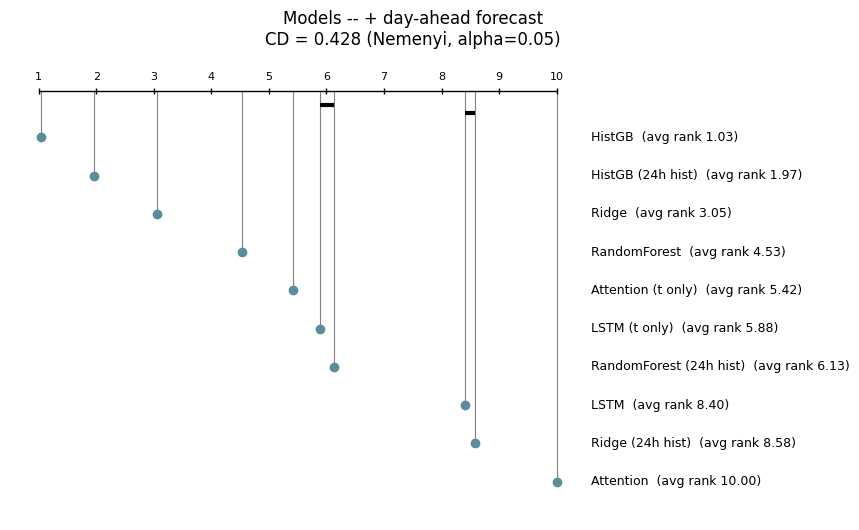

43 of 45 pairs differ significantly (Nemenyi, alpha=0.05):


,model_a,model_b,rank_diff,significant
0,HistGB,Attention,8.966,True
1,HistGB (24h hist),Attention,8.034,True
2,HistGB,Ridge (24h hist),7.546,True
3,HistGB,LSTM,7.367,True
4,Ridge,Attention,6.946,True
5,HistGB (24h hist),Ridge (24h hist),6.614,True
6,HistGB (24h hist),LSTM,6.435,True
7,Ridge,Ridge (24h hist),5.526,True
8,RandomForest,Attention,5.470,True
9,Ridge,LSTM,5.347,True


In [25]:
err_by_model = {
    m: np.abs(y_test.values - predictions[(m, fs_best)].values)
    for m in MODEL_ORDER
}
boot_scores_models = block_bootstrap_scores(err_by_model, n_test=len(test))
avg_ranks_models, cd_models, stat_models, p_models, sig_models = friedman_nemenyi(boot_scores_models)

print(f"Friedman test across {len(MODEL_ORDER)} models on '{fs_best}': "
     f"statistic={stat_models:.2f}, p={p_models:.2e}")
print("=> ranks differ significantly overall" if p_models < 0.05 else
     "=> no significant overall difference detected across models")

plot_cd_diagram(avg_ranks_models, cd_models, f"Models -- {fs_best}")

sig_only_models = sig_models[sig_models["significant"]]
if len(sig_only_models):
    print(f"{len(sig_only_models)} of {len(sig_models)} pairs differ significantly (Nemenyi, alpha=0.05):")
    display(sig_only_models)
else:
    print("No individual pair of models differs significantly at alpha=0.05 -- "
         "treat the ranking in 2.8/2.8c as suggestive, not conclusive.")


**Rungs comparison — all five feature-set rungs, represented by `HistGB`.**

Friedman test across 5 rungs (HistGB): statistic=2577.96, p=0.00e+00
=> ranks differ significantly overall


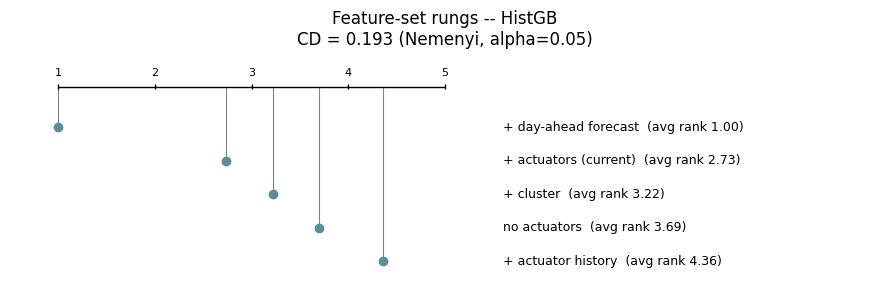

10 of 10 pairs differ significantly (Nemenyi, alpha=0.05):


,model_a,model_b,rank_diff,significant
0,+ day-ahead forecast,+ actuator history,3.357,True
1,+ day-ahead forecast,no actuators,2.695,True
2,+ day-ahead forecast,+ cluster,2.218,True
3,+ day-ahead forecast,+ actuators (current),1.730,True
4,+ actuators (current),+ actuator history,1.627,True
5,+ cluster,+ actuator history,1.139,True
6,+ actuators (current),no actuators,0.965,True
7,no actuators,+ actuator history,0.662,True
8,+ actuators (current),+ cluster,0.488,True
9,+ cluster,no actuators,0.477,True


In [26]:
rung_compare_model = "HistGB"  # same representative model 2.9's ablation checks use
err_by_rung = {
    fs: np.abs(y_test.values - predictions[(rung_compare_model, fs)].values)
    for fs in feature_sets
}
boot_scores_rungs = block_bootstrap_scores(err_by_rung, n_test=len(test))
avg_ranks_rungs, cd_rungs, stat_rungs, p_rungs, sig_rungs = friedman_nemenyi(boot_scores_rungs)

print(f"Friedman test across {len(feature_sets)} rungs ({rung_compare_model}): "
     f"statistic={stat_rungs:.2f}, p={p_rungs:.2e}")
print("=> ranks differ significantly overall" if p_rungs < 0.05 else
     "=> no significant overall difference detected across rungs")

plot_cd_diagram(avg_ranks_rungs, cd_rungs, f"Feature-set rungs -- {rung_compare_model}")

sig_only_rungs = sig_rungs[sig_rungs["significant"]]
if len(sig_only_rungs):
    print(f"{len(sig_only_rungs)} of {len(sig_rungs)} pairs differ significantly (Nemenyi, alpha=0.05):")
    display(sig_only_rungs)
else:
    print("No individual pair of rungs differs significantly at alpha=0.05 -- "
         "treat the ladder in 2.8 as suggestive, not conclusive.")


## 2.9 — ❓ Does the climatic-system data actually help?

This is the core question. Two complementary views:

* **Ablation delta** — per-target MAE with *no actuators* vs *+ actuator history*. A **negative** number means the climatic-system features *reduced* the error.
* **Importance share** — how much of a Random Forest's decision weight the actuator features (current + history) collect.

In [27]:
best_model_for_ablation = "HistGB"
no_act = results[(best_model_for_ablation, "no actuators")]["MAE"]
with_act = results[(best_model_for_ablation, "+ actuator history")]["MAE"]
ablation = pd.DataFrame({
    "MAE no actuators": no_act,
    "MAE + actuators":  with_act,
    "delta (neg=help)": with_act - no_act,
})
print(f"Ablation for {best_model_for_ablation}:")
ablation.round(3)

Ablation for HistGB:


,MAE no actuators,MAE + actuators,delta (neg=help)
temp_h1,0.656,0.693,0.036
hum_h1,2.177,2.215,0.038
temp_h6,1.271,1.371,0.100
hum_h6,4.019,4.307,0.288
temp_h12,1.284,1.333,0.050
hum_h12,5.108,4.837,-0.271


### 2.9b — Does the day-ahead forecast help?

Same idea as the actuator ablation above, but for the new **`+ day-ahead forecast`** rung: compare `+ cluster` (no day-ahead forecast) against `+ day-ahead forecast`, same model.


In [28]:
no_fc = results[(best_model_for_ablation, "+ cluster")]["MAE"]
with_fc = results[(best_model_for_ablation, "+ day-ahead forecast")]["MAE"]
fc_ablation = pd.DataFrame({
    "MAE no day-ahead fc": no_fc,
    "MAE + day-ahead fc":  with_fc,
    "delta (neg=help)":    with_fc - no_fc,
})
print(f"Day-ahead forecast ablation for {best_model_for_ablation}:")
fc_ablation.round(3)


Day-ahead forecast ablation for HistGB:


,MAE no day-ahead fc,MAE + day-ahead fc,delta (neg=help)
temp_h1,0.689,0.657,-0.032
hum_h1,2.163,2.226,0.063
temp_h6,1.335,0.929,-0.406
hum_h6,4.413,3.785,-0.627
temp_h12,1.328,0.965,-0.363
hum_h12,4.650,3.255,-1.395


In [29]:
rf_imp = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                               n_jobs=-1, random_state=0).fit(
    train[feature_sets["+ actuator history"]], y_train)
imp = pd.Series(rf_imp.feature_importances_,
                index=feature_sets["+ actuator history"]).sort_values(ascending=False)
act_share = imp[actuator_features].sum()
print(f"Climatic-system features hold {act_share:.1%} of total RF importance "
      f"(vs ~0.4% on the full un-scoped year).")
print("Top climatic-system features:")
print(imp[actuator_features].sort_values(ascending=False).head(8).round(4).to_string())

Climatic-system features hold 9.2% of total RF importance (vs ~0.4% on the full un-scoped year).
Top climatic-system features:
act_calefactores_r3        0.0212
act_calefactores_r6        0.0116
act_calefactores           0.0039
act_vent_lat_norte_r6      0.0035
act_vent_lat_oeste_r6      0.0032
act_pantalla_cenital_r6    0.0030
act_recirculador_r6        0.0030
act_fog_r6                 0.0029


**Interpretation (read together with your run's numbers).**

* After scoping to the active period and adding history, the climatic-system features climb to a **double-digit share** of Random-Forest importance — they are genuinely *used*. `act_calefactores_r3` (recent heating) and the rolling vent/recirculator terms lead, which is physically sensible.
* **Yet the ablation delta is close to zero** — removing them barely changes the error. Why? Their thermodynamic effect (a vent opening cools and dries the air) is *already visible* in the interior temperature/humidity/pressure sensors the model reads directly, so the actuator columns are largely **redundant** with the climate block. On top of that the scoped dataset is small (~1.2k train hours), so extra columns can add as much noise as signal.

**Takeaway:** the climatic systems are fully part of the analysis and are the *most* informative once history is added — but for *forecasting* they mostly duplicate information the sensors already carry. They would matter more for a **control / what-if** model (predicting the effect of *changing* an actuator), which the "Next steps" cell sketches.

## 2.10 — Algorithm comparison (richest feature set) by horizon

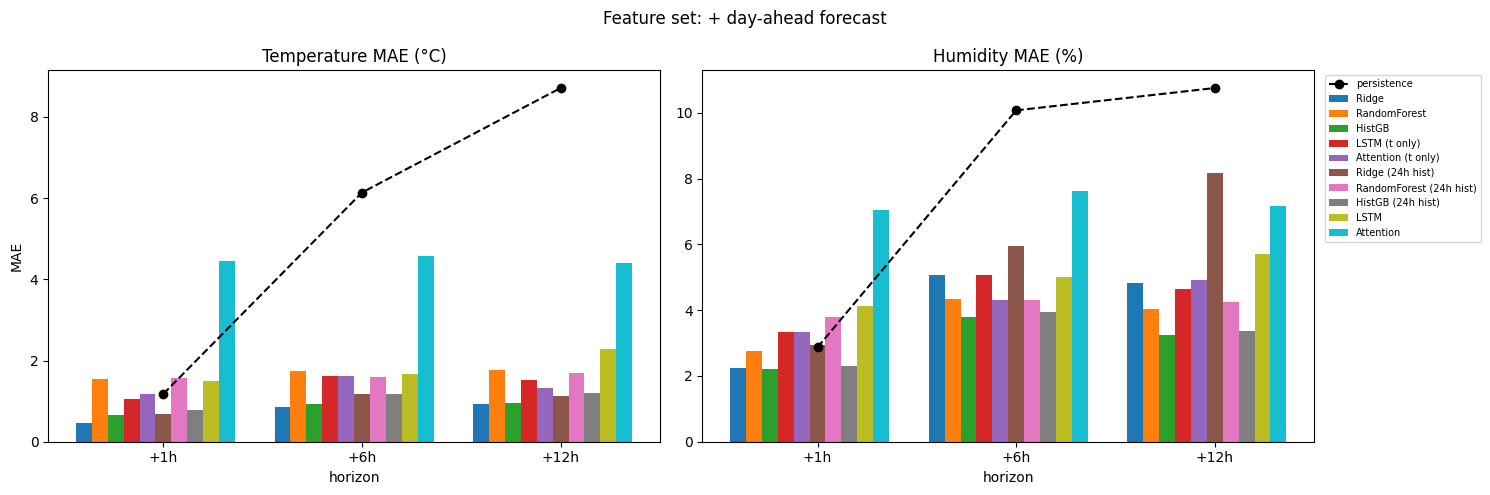

In [30]:
fs_show = "+ day-ahead forecast"   # now the richest rung
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, var, label in zip(axes, ["temp", "hum"],
                          ["Temperature MAE (°C)", "Humidity MAE (%)"]):
    cols = [f"{var}_h{h}" for h in (1, 6, 12)]
    x = np.arange(3); models = MODEL_ORDER; w = 0.8/len(models)
    for i, m in enumerate(models):
        ax.bar(x + i*w, results[(m, fs_show)].loc[cols, "MAE"].values, w, label=m)
    ax.plot(x + w*len(models)/2, baseline_scores.loc[cols, "MAE"].values,
            "k--o", label="persistence")
    ax.set_xticks(x + 0.4); ax.set_xticklabels(["+1h","+6h","+12h"])
    ax.set_title(label); ax.set_xlabel("horizon")
axes[0].set_ylabel("MAE"); axes[1].legend(bbox_to_anchor=(1.01,1), fontsize=7)
plt.suptitle(f"Feature set: {fs_show}"); plt.tight_layout(); plt.show()


**How to read this.** The gap between the bars and the dashed baseline is the value the model adds. At **+1h** persistence is already strong; at **+6h/+12h** the learned models pull clearly ahead by exploiting the daily cycle and the weather forecast.

## 2.11 — Predicted vs actual (best model overall)

All three horizons (**+1h / +6h / +12h**) for both **temperature** and **humidity** — every target the model predicts, not just a representative subset.


best: ('HistGB', '+ day-ahead forecast') | mean MAE = 1.97


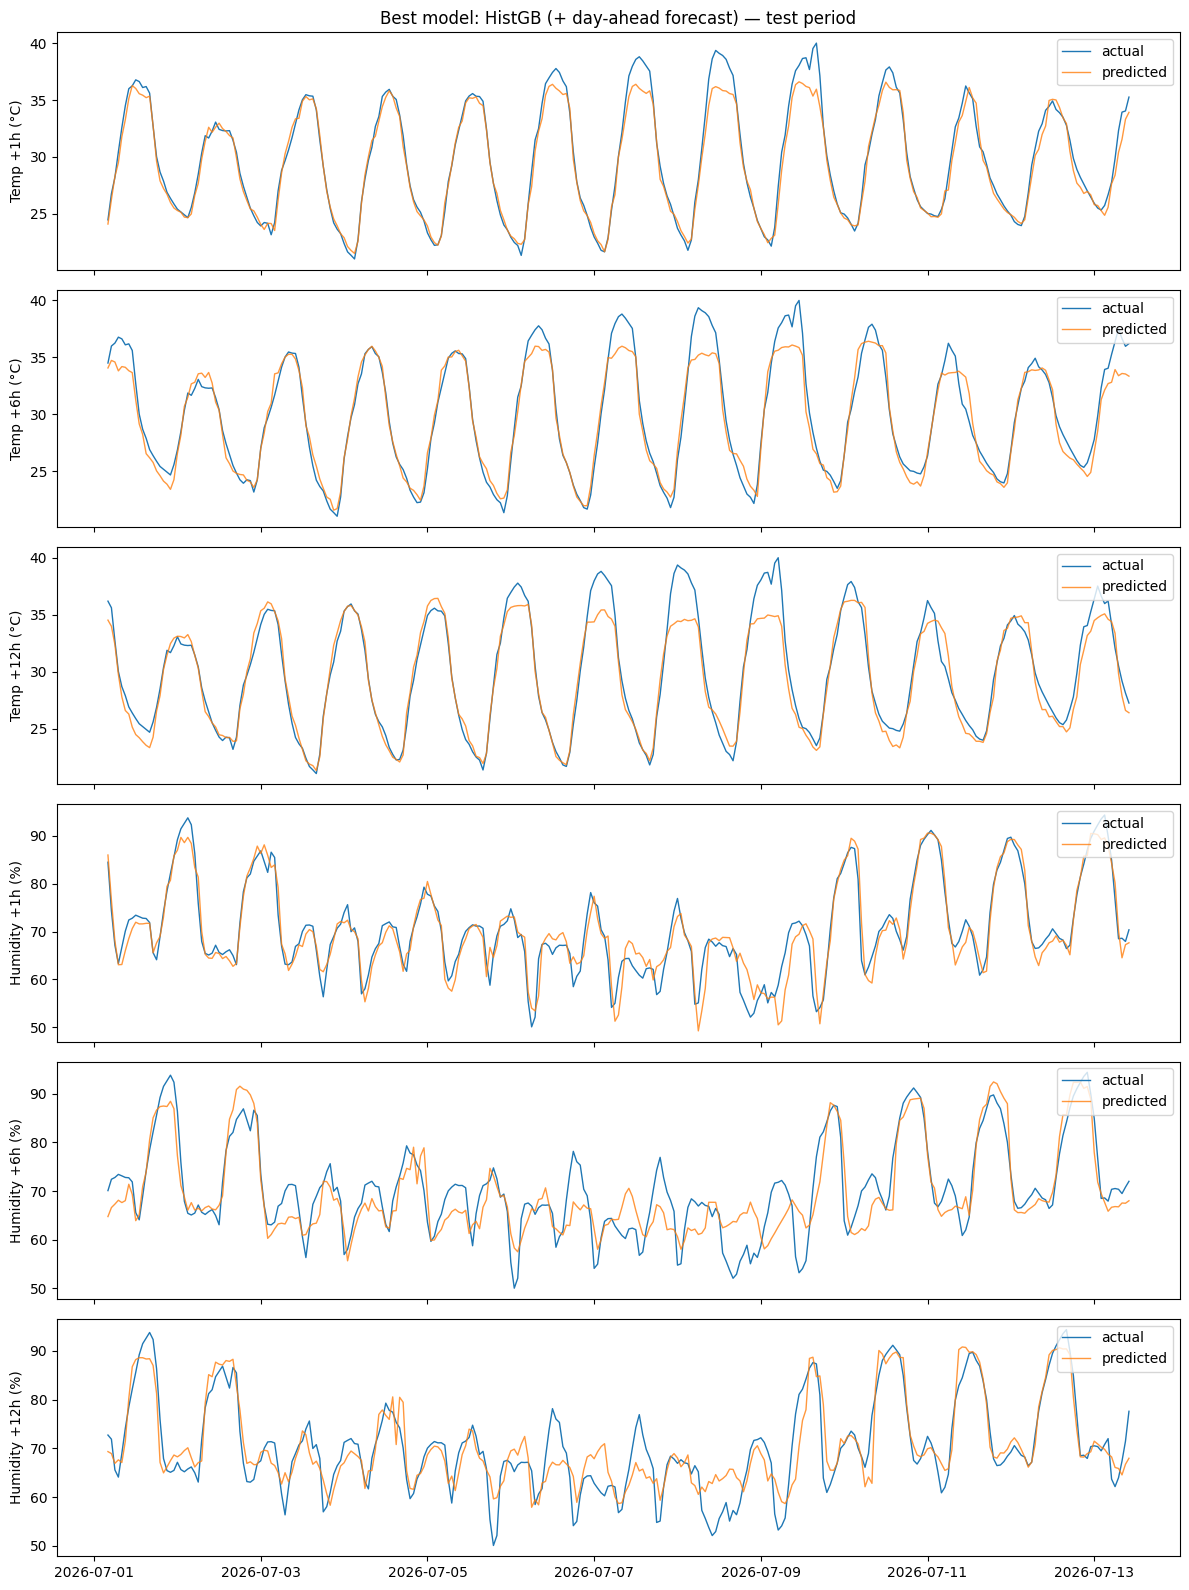

In [31]:
avg_mae = {k: v["MAE"].mean() for k, v in results.items()}
best_key = min(avg_mae, key=avg_mae.get)
print("best:", best_key, "| mean MAE =", round(avg_mae[best_key], 3))
best_pred = predictions[best_key]

cols_to_plot = ["temp_h1", "temp_h6", "temp_h12", "hum_h1", "hum_h6", "hum_h12"]
labels = ["Temp +1h (°C)", "Temp +6h (°C)", "Temp +12h (°C)",
         "Humidity +1h (%)", "Humidity +6h (%)", "Humidity +12h (%)"]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 16), sharex=True)
for ax, col, ylab in zip(axes, cols_to_plot, labels):
    ax.plot(test.index, y_test[col], label="actual", lw=1)
    ax.plot(test.index, best_pred[col], label="predicted", lw=1, alpha=0.8)
    ax.set_ylabel(ylab); ax.legend(loc="upper right")
axes[0].set_title(f"Best model: {best_key[0]} ({best_key[1]}) — test period")
plt.tight_layout(); plt.show()


## 2.12 — Feature importance, climatic systems highlighted

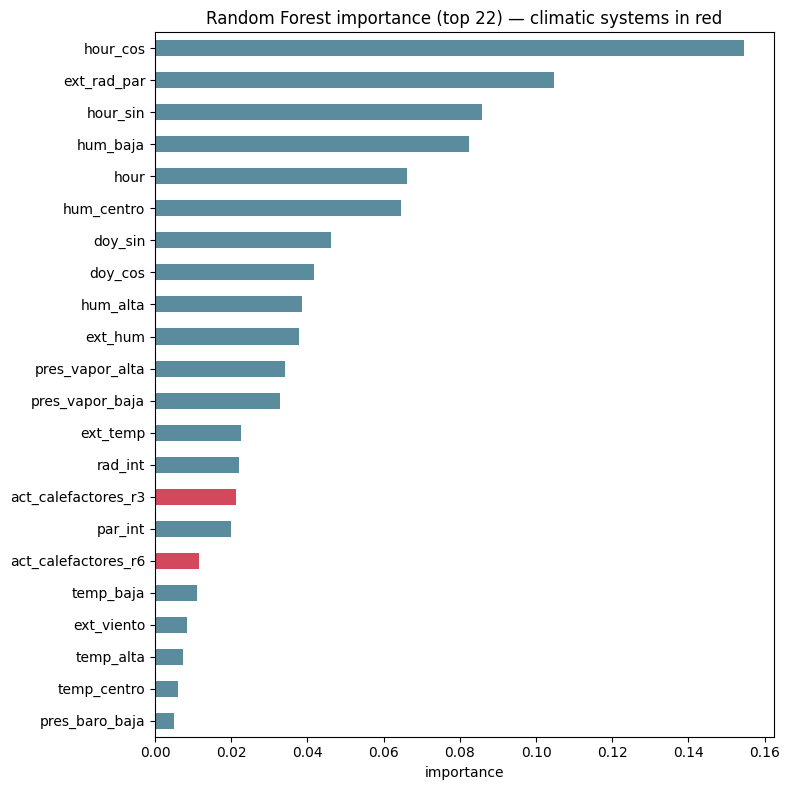

In [32]:
top = imp.head(22).iloc[::-1]
colors = ["#d1495b" if f in actuator_features else "#5b8c9e" for f in top.index]
top.plot(kind="barh", color=colors, figsize=(8, 8))
plt.title("Random Forest importance (top 22) — climatic systems in red")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

### 2.12b — Permutation importance (test-set, generalization-based)

2.12's bars are **impurity-based** importance (`rf_imp.feature_importances_`, from 2.9): the mean decrease in variance credited to each feature across every split in the forest, computed while *fitting* on `train`. It says what the forest **used** to fit the training data — it doesn't measure what actually helps it generalize, and it's known to inflate high-cardinality/continuous features and split credit arbitrarily across correlated columns.

Permutation importance is a complementary, generalization-based measure of the *same, already-fitted* `rf_imp` model — **no new model is trained here, and nothing in 2.9/2.12 is recomputed or changed.** On the held-out `test` set, `sklearn.inspection.permutation_importance` repeatedly shuffles one feature column at a time and measures how much the model's score (`neg_mean_absolute_error`) drops. A feature the model actually relies on for accurate *test* predictions shows a large drop when shuffled; an unused or redundant one shows close to zero (or even a small positive "drop" from pure noise). `n_repeats=20` gives each feature a mean and a standard deviation, shown as error bars in the plot below.

Note the climatic-system "% share" figure below isn't directly comparable to 2.9/2.12's: impurity importance is non-negative and sums to a meaningful total by construction, while permutation importance can come out slightly negative for irrelevant features from pure noise — so the share here is computed over the *clipped-to-zero* positive importances only, as an approximation, not an exact analogue.


In [33]:
from sklearn.inspection import permutation_importance

# Reuses the exact `rf_imp` fitted in 2.9 (cell above 2.12) -- does not refit,
# does not touch `imp` / `act_share` / any other existing variable or result.
perm_cols = feature_sets["+ actuator history"]
perm_result = permutation_importance(
    rf_imp, test[perm_cols], y_test,
    scoring="neg_mean_absolute_error", n_repeats=20, random_state=0, n_jobs=-1)

perm_imp = pd.Series(perm_result.importances_mean, index=perm_cols).sort_values(ascending=False)
perm_imp_std = pd.Series(perm_result.importances_std, index=perm_cols)

act_share_perm = (perm_imp[actuator_features].clip(lower=0).sum()
                  / perm_imp.clip(lower=0).sum())
print(f"Climatic-system features hold {act_share_perm:.1%} of total (positive) permutation "
      f"importance on the test set -- compare with the {act_share:.1%} impurity-based figure in 2.9/2.12.")
print("Top climatic-system features by permutation importance:")
print(perm_imp[actuator_features].sort_values(ascending=False).head(8).round(4).to_string())


Climatic-system features hold 4.6% of total (positive) permutation importance on the test set -- compare with the 9.2% impurity-based figure in 2.9/2.12.
Top climatic-system features by permutation importance:
act_fog_r6                 0.0248
act_fog_r3                 0.0174
act_pantalla_cenital_r6    0.0163
act_vent_lat_oeste_r6      0.0136
act_vent_lat_norte_r3      0.0105
act_pantalla_lat_sur_r6    0.0092
act_pantalla_cenital_r3    0.0090
act_recirculador_r3        0.0089


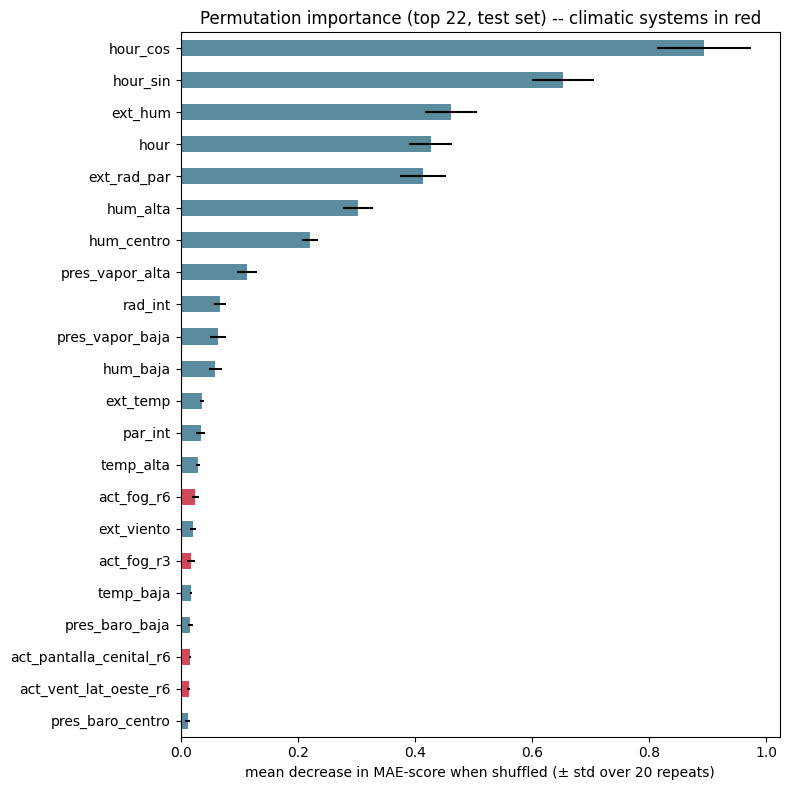

In [34]:
top_perm = perm_imp.head(22).iloc[::-1]
top_perm_std = perm_imp_std.reindex(top_perm.index)
colors_perm = ["#d1495b" if f in actuator_features else "#5b8c9e" for f in top_perm.index]
top_perm.plot(kind="barh", xerr=top_perm_std, color=colors_perm, figsize=(8, 8))
plt.title("Permutation importance (top 22, test set) -- climatic systems in red")
plt.xlabel("mean decrease in MAE-score when shuffled (\u00b1 std over 20 repeats)")
plt.tight_layout(); plt.show()


## 2.13 — Real vs. predicted Vapour Pressure Deficit (VPD)

VPD is a derived quantity, not a raw sensor — it is computed from temperature and humidity, so this checks whether the two per-target errors from the best model (**HistGB**) compound or cancel once combined into the value growers actually act on. **Real VPD** comes straight from `temp_centro` / `hum_centro` (via the h-hour-ahead targets, which are just those two columns shifted); **predicted VPD** uses the same model's temperature and humidity forecasts, at each horizon.

In [35]:
def vpd_kpa(temp_c, rh_pct):
    """Vapour pressure deficit (kPa) from temperature (°C) and relative humidity (%), Tetens equation."""
    es = 0.6108 * np.exp(17.27 * temp_c / (temp_c + 237.3))
    return es * (1 - rh_pct / 100.0)

horizons = (1, 6, 12)
vpd_real = pd.DataFrame({h: vpd_kpa(y_test[f"temp_h{h}"], y_test[f"hum_h{h}"]) for h in horizons})
vpd_best = pd.DataFrame({h: vpd_kpa(best_pred[f"temp_h{h}"], best_pred[f"hum_h{h}"]) for h in horizons})
vpd_real.columns.name = vpd_best.columns.name = "horizon (h)"

vpd_scores = pd.DataFrame({
    "MAE":    {h: mean_absolute_error(vpd_real[h], vpd_best[h]) for h in horizons},
    "CVRMSE": {h: cvrmse(vpd_real[h], vpd_best[h]) for h in horizons},
    "R2":     {h: np.corrcoef(vpd_real[h], vpd_best[h])[0][1]**2 for h in horizons},
})
vpd_scores.index.name = "horizon (h)"
print(f"VPD from best model: {best_key[0]} ({best_key[1]})  |  units: kPa for MAE, unitless for CVRMSE/R2")
vpd_scores.round(3)

VPD from best model: HistGB (+ day-ahead forecast)  |  units: kPa for MAE, unitless for CVRMSE/R2


,MAE,CVRMSE,R2
horizon (h),,,
1,0.116,0.139,0.914
6,0.176,0.186,0.837
12,0.164,0.181,0.856


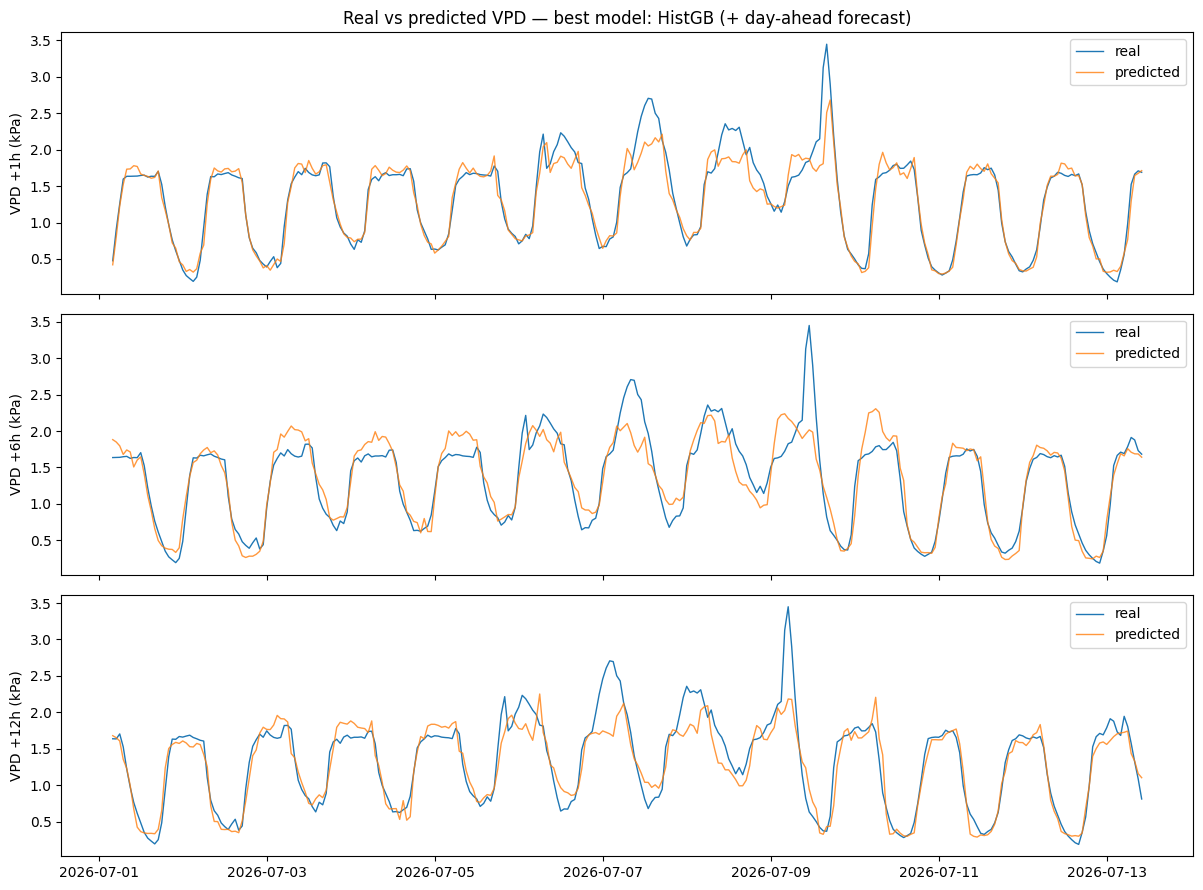

In [36]:
fig, axes = plt.subplots(len(horizons), 1, figsize=(12, 9), sharex=True)
for ax, h in zip(axes, horizons):
    ax.plot(test.index, vpd_real[h], label="real", lw=1)
    ax.plot(test.index, vpd_best[h], label="predicted", lw=1, alpha=0.8)
    ax.set_ylabel(f"VPD +{h}h (kPa)"); ax.legend(loc="upper right")
axes[0].set_title(f"Real vs predicted VPD — best model: {best_key[0]} ({best_key[1]})")
plt.tight_layout(); plt.show()

## Summary & next steps

* Interior **temperature + humidity** at **+1h / +6h / +12h** framed as one multi-output regression, scoped to the period where all climatic systems operate.
* All learned models beat persistence, the advantage **growing with horizon**; gradient boosting / random forest are strongest among the single-timestep tabular models.
* **Full 3×2 architecture comparison (2.7b–2.7g).** Ridge/RandomForest/HistGB, the LSTM, and a compact attention-based (Transformer-encoder) model are each trained twice — once single-timestep, once on the flattened/sequential 24h window — so the ladder in 2.8 separates three different questions: does *history* help (compare a model against its own "(24h hist)"/"(t only)" counterpart), does the *LSTM* help over tabular models given the same information, and does *attention* help over either of them (compare LSTM vs Attention within either input regime). With ~1.2k training hours both neural architectures are data-hungry relative to the tabular models, so neither is guaranteed to win — see the ladder (2.8) and best-model report (2.8b) for how they actually compare once you run the notebook.
* **Attention model is intentionally a scaled-down TFT-style block, not a full Temporal Fusion Transformer** (see 2.7f for the reasoning) — one multi-head self-attention layer plus a small feed-forward block, at a parameter budget close to the LSTM's, so the comparison is about the *attention mechanism* rather than the extra machinery (variable-selection networks, gating, quantile loss) a production TFT would add.
* **Hyperparameter tuning for all models, Bayesian for the neural ones (2.7b–2.7h).** Ridge/RandomForest/HistGB search a small fixed grid; the LSTM and Attention models are tuned by KerasTuner's `BayesianOptimization` (`tune_neural()`, 2.7d) over `units`, `dropout`, learning rate and `optimizer` — a real mixed continuous/categorical search rather than a hand-picked list, still scored on a chronological hold-out inside `train` so it can't see `test`. 2.7h shows exactly what won for each model × rung (e.g. a much larger Ridge `alpha` on the "(24h hist)" rungs signals how much more regularisation that higher columns-to-rows ratio needs; a Bayesian search consistently landing on non-zero `dropout` for the neural models would suggest they were overfitting at `dropout=0`).
* **Day-ahead forecast, aligned per horizon (2.1/2.3).** The `+ day-ahead forecast` rung adds, for each horizon, the `previous_day1` Open-Meteo forecast value for the *target* hour — a forecast genuinely known about a day in advance, unlike the un-suffixed `fc_*` columns, which are excluded from every model input (see the note in 2.3). The 2.9b ablation cell measures its marginal value the same way the actuator ablation does.
* The **climatic-system features** (heaters, fog, vents, screens, pumps…) are fully included and — once scoped and given rolling **history** — become the most-used engineered features (double-digit importance share). However the **ablation shows they add little forecasting accuracy**, because their effect is already reflected in the interior sensors.

**Ideas to push further**
* **Control / what-if model:** predict the *change* in temperature/humidity caused by opening a vent or running fog — here the actuators are the *inputs you set*, so they become decisive (this is where the climatic-system data pays off most).
* `max_trials=8` in `tune_neural()` is deliberately small to bound runtime; if 2.7h shows the neural models' winners are noisy or inconsistent across rungs, that's a signal the Bayesian search hasn't had enough trials to converge — raising `max_trials`, or switching to `kt.Hyperband` (which allocates its budget more adaptively across many cheap short runs plus a few longer ones), would be the next step before trusting the winners too much.
* If the attention model is competitive, a natural next step toward an actual TFT is adding the pieces skipped here: a variable-selection network (learned per-feature gating instead of feeding every column identically), separate handling of the day-ahead forecast columns as "known future inputs" versus the sensor columns as "observed past", and a quantile loss for uncertainty bands instead of a point MAE.
* Collect more than one season so the re-scoped window is larger and covers more regimes (would also help the LSTM, Attention, and the `(24h hist)` tabular models, which all benefit most from more training sequences).
* `TimeSeriesSplit` cross-validation (rather than a single inner hold-out) for a less noisy hyperparameter choice; try direct-vs-recursive multi-horizon strategies.
* Feed the control **rules** (`inside data/rules/`) as setpoint features.
